In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path
import numpy as np
import pandas as pd

from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

import aind_hcr_qc.viz as viz
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins
from aind_hcr_qc.viz.single_cell_unmixing import (
    plot_spot_projection,
    plot_spot_measure_distributions,
    plot_cell_qc,
    plot_spot_nn_distances,
    plot_adjacent_channel_scatter,
)


import aind_hcr_qc.viz.single_cell_unmixing as scu

from aind_hcr_qc.viz.spot_detection import (
    annotate_spots_df,
    plot_removal_metric_distributions,
)
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT

In [2]:
import sys, importlib
sys.path.insert(0, '/root/capsule/code/cluster_validation')
import atlas_compare
importlib.reload(atlas_compare)


<module 'atlas_compare' from '/root/capsule/code/cluster_validation/atlas_compare.py'>

In [9]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [9]:
# ── configuration ────────────────────────────────────────────────────────────
MOUSE_ID = "782149"
  # use a mouse that has a pairwise_unmixing derived asset
CATALOG_PATH = Path(f"/src/ophys-mfish-dataset-catalog/mice/{MOUSE_ID}.json")
DATA_DIR     = Path("/root/capsule/data")
OUTPUT_DIR = Path(f"/root/capsule/scratch/ref_atlas_validation/{MOUSE_ID}")

# ── attach & load ────────────────────────────────────────────────────────────
record  = MouseRecord.from_json_file(CATALOG_PATH)
results = attach_mouse_record_to_workstation(record)
print_attach_results(results)

dataset = create_hcr_dataset_from_schema(CATALOG_PATH, DATA_DIR)
dataset.summary()

# ── pairwise unmixing (optional) ─────────────────────────────────────────────
# The pairwise asset name lives in derived_assets["pairwise_unmixing"] when present.
pairwise_asset_name = record.derived_assets.get("pairwise_unmixing")

if pairwise_asset_name is not None:
    pairwise_asset_path = DATA_DIR / pairwise_asset_name
    # Some pipeline outputs nest data under a "pairwise_unmixing" subfolder
    if (pairwise_asset_path / "pairwise_unmixing").exists():
        pairwise_asset_path = pairwise_asset_path / "pairwise_unmixing"
    pw_ds = create_pairwise_unmixing_dataset(
        mouse_id=MOUSE_ID,
        pairwise_asset_path=pairwise_asset_path,
        source_dataset=dataset,   # delegates zarr / segmentation calls
        min_dist=1
    )
    pw_ds.summary()
else:
    print("No pairwise_unmixing asset found in catalog record — skipping.")


  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-04-29_18-02-29  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29/image_spot_spectral_unmixing exists=True
[DEBUG get_spot_files] .pkl files in folder: ['unmixe

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2500: UserWarning: [get_spot_files] R1: no unmixed_spots_R1*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2509: UserWarning: [get_spot_files] R1: no mixed_spots_R1.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26/image_spot_spectral_unmixing exists=True
[DEBUG get_spot_files] .pkl files in folder: ['mixed_spots_R-1.pkl', 'unmixed_spots_R5_minDist_3.pkl', 'unmixed_spots_R-1_minDist_3.pkl', 'mixed_spots_R5.pkl']
[DEBUG get_spot_files] unmixed_spots=/root/capsule/data/HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26/image_spot_spectral_unmixing/unmixed_spots_R5_minDist_3.pkl  mixed_spots=/root/capsule/data/HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26/image_spot_spectral_unmixing/mixed_spots_R5.pkl
mouse_id: 782149
Could not load metadata for mouse 782149
Cell-typing asset attached: CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
HCR Dataset Summary
Mouse ID: 782149
Rounds: R1, R2, R3, R4, R5

Channels by round:
  R1: 594, 405, 488, 561
  R2: 488, 405, 514, 561, 638, 594
  R3: 514, 488, 405, 561, 594, 638
  R4: 51

In [10]:

# channel display order and fixed colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}

# ── load spots (both tables) for this cell ───────────────────────────────────
mixed_spots   = pw_ds.load_all_rounds_spots_mp(table_type="mixed_spots", remove_fg_bg_cols=True)
unmixed_spots = pw_ds.load_all_rounds_spots_mp(table_type="unmixed_spots",  remove_fg_bg_cols=False)

unmixed_spots_valid = unmixed_spots[unmixed_spots["valid_spot"]]

# ── Annotate once (valid_spot-aware) ──────────────────────────────────────────
mixed_ann, unmixed_ann = scu.annotate_spots_with_valid(mixed_spots, unmixed_spots)

Loading mixed_spots for round R1: 782149_R1
Loading mixed_spots for round R2: 782149_R2

Loading mixed_spots for round R3: 782149_R3

Loading mixed_spots for round R4: 782149_R4
Loading mixed_spots for round R5: 782149_R5





Number of mixed_spots: 3.628e+07
Loading unmixed_spots for round R1: 782149_R1

Loading unmixed_spots for round R2: 782149_R2
Loading unmixed_spots for round R3: 782149_R3
Loading unmixed_spots for round R4: 782149_R4



Loading unmixed_spots for round R5: 782149_R5

Number of unmixed_spots: 3.075e+07


In [11]:
cluster_labels = pw_ds.load_cluster_labels().squeeze()
cluster_cids = pw_ds.load_sorted_cell_ids().squeeze()
cluster_meta = pd.DataFrame({"cluster_label": cluster_labels, "cell_id": cluster_cids})
cluster_meta = cluster_meta.set_index("cell_id")



In [12]:
# Build Round-Chan-Gene display labels from the spot table
gene_labels = (
    mixed_spots[["mixed_gene", "round", "chan"]]
    .drop_duplicates("mixed_gene")
    .set_index("mixed_gene")
    .apply(lambda r: f"{r['round']}-{r['chan']}-{r.name}", axis=1)
    .to_dict()
)

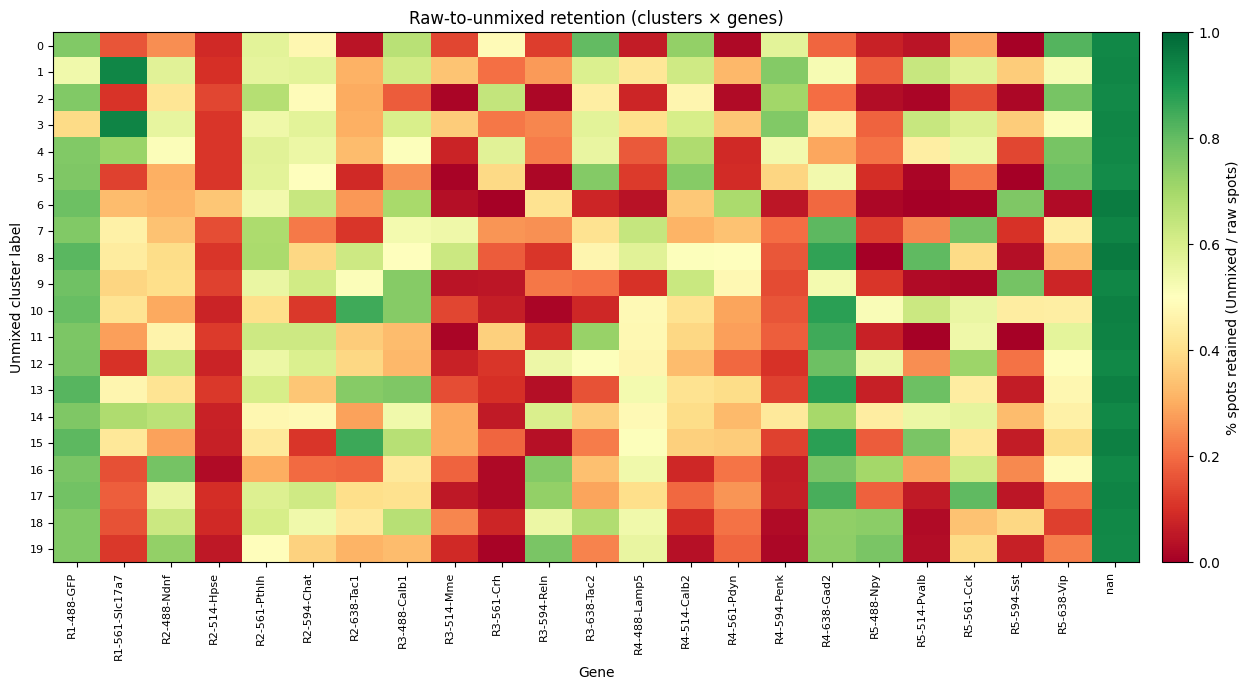

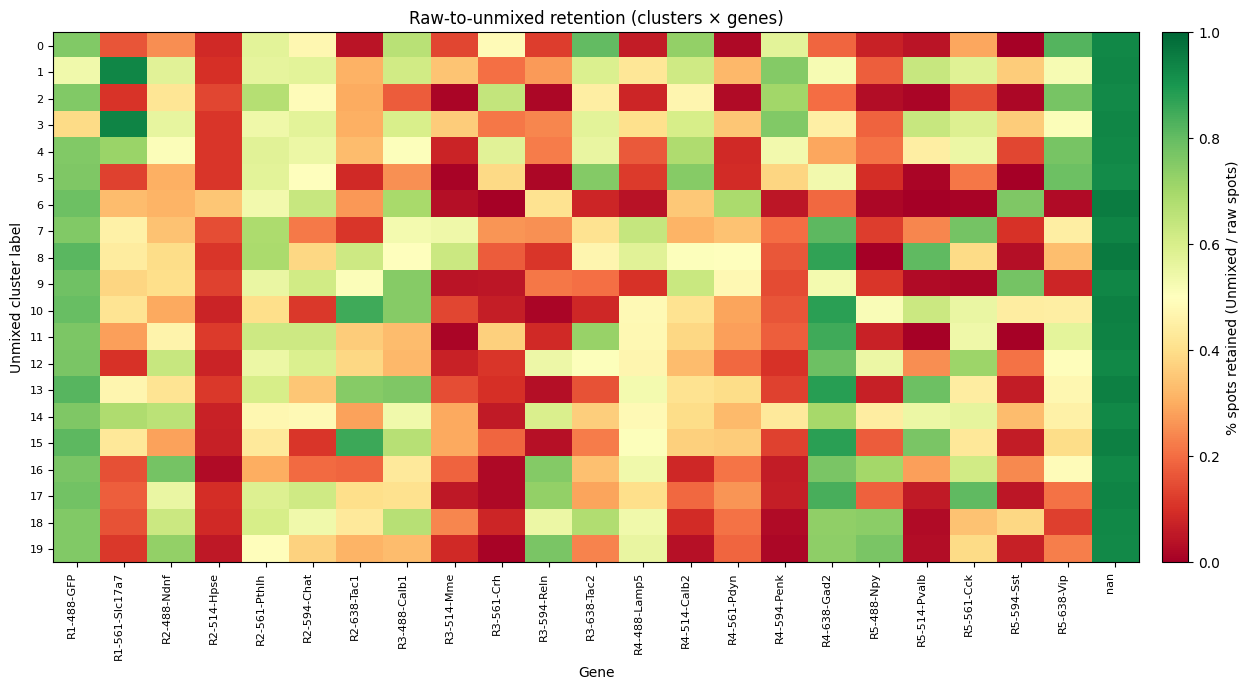

In [13]:
# Filter out unassigned spots (cell_id == 0) before passing to atlas_compare.
# atlas_compare joins to cluster_meta internally via cell_id — no merge needed.
mixed_spots   = mixed_ann[mixed_ann["cell_id"] > 0]
unmixed_spots = unmixed_ann[unmixed_ann["cell_id"] > 0]

retention = atlas_compare.gene_retention_by_group(
    raw_spots=mixed_spots,
    unmixed_spots=unmixed_spots_valid,
    cell_meta=cluster_meta,          # indexed by cell_id, has "cluster_label"
    group_col="cluster_label",
    raw_chan_col="mixed_gene",
    unmixed_chan_col="unmixed_gene",
)

# Build Round-Chan-Gene display labels from the spot table
gene_labels = (
    mixed_spots[["mixed_gene", "round", "chan"]]
    .drop_duplicates("mixed_gene")
    .set_index("mixed_gene")
    .apply(lambda r: f"{r['round']}-{r['chan']}-{r.name}", axis=1)
    .to_dict()
)

# col_sort="label" groups by round then channel; row_sort="natural" keeps cluster numeric order
atlas_compare.plot_retention_heatmap(
    retention, min_raw_spots=5, gene_labels=gene_labels,
    col_sort="label", row_sort="natural",
)

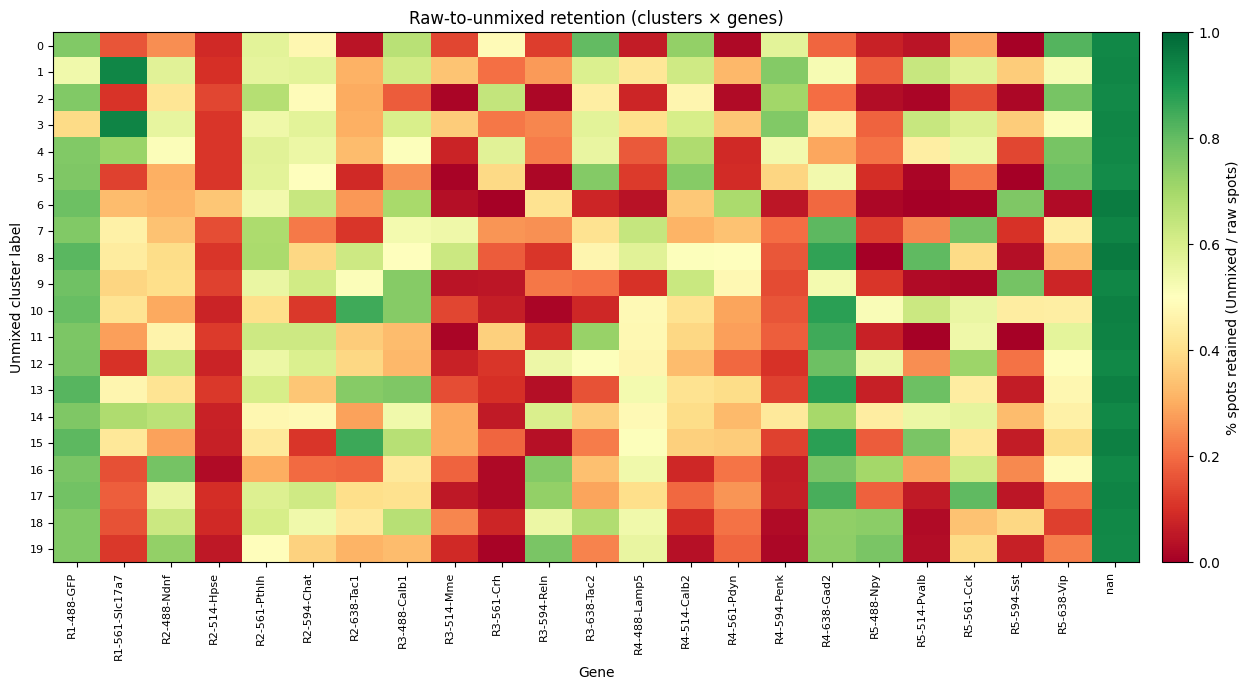

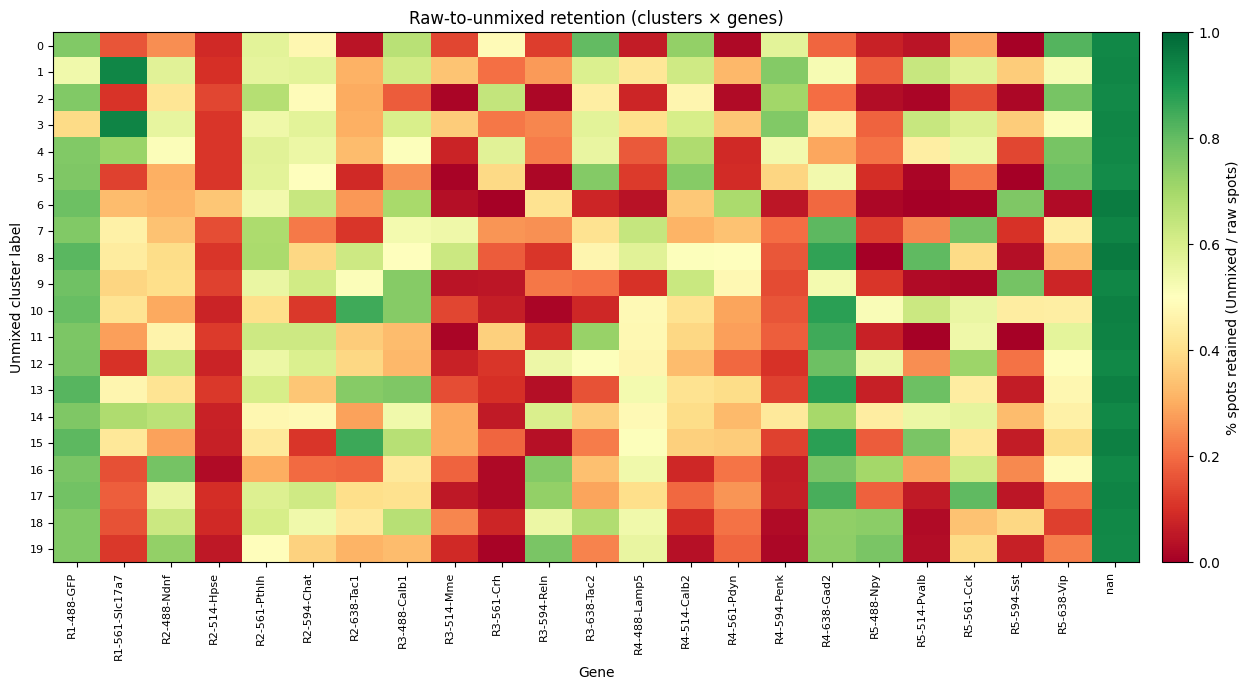

In [14]:
# Build Round-Chan-Gene display labels from the spot table
gene_labels = (
    mixed_spots[["mixed_gene", "round", "chan"]]
    .drop_duplicates("mixed_gene")
    .set_index("mixed_gene")
    .apply(lambda r: f"{r['round']}-{r['chan']}-{r.name}", axis=1)
    .to_dict()
)

# col_sort="label" groups by round then channel; row_sort="natural" keeps cluster numeric order
atlas_compare.plot_retention_heatmap(
    retention, min_raw_spots=5, gene_labels=gene_labels,
    col_sort="label", row_sort="natural",
)

# plot cell x gene

In [20]:
from importlib import reload
reload(atlas_compare)

<module 'atlas_compare' from '/root/capsule/code/cluster_validation/atlas_compare.py'>

In [21]:
%matplotlib inline

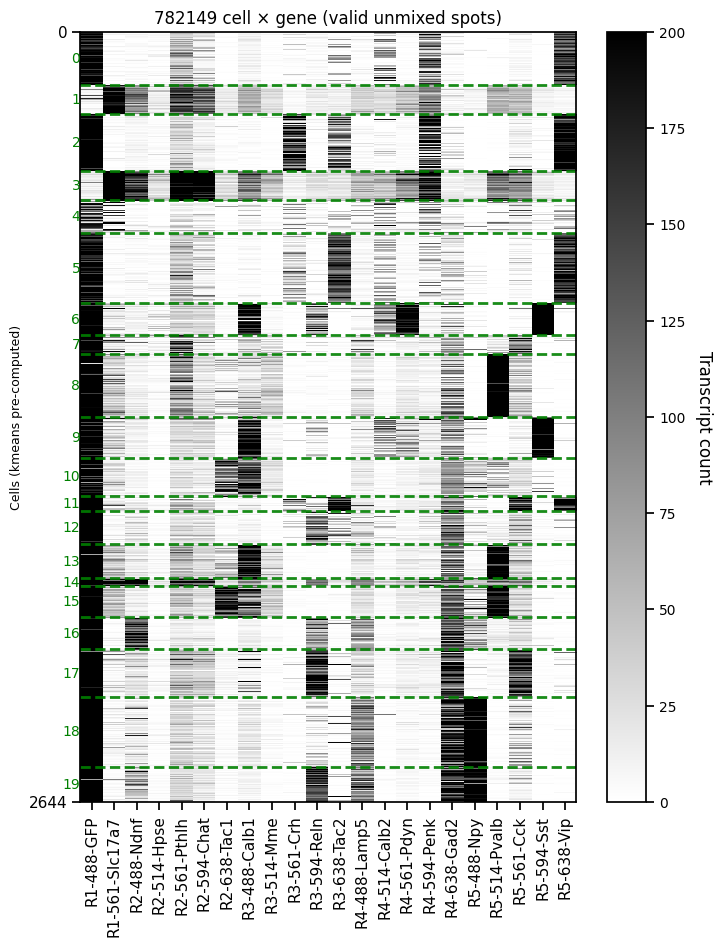

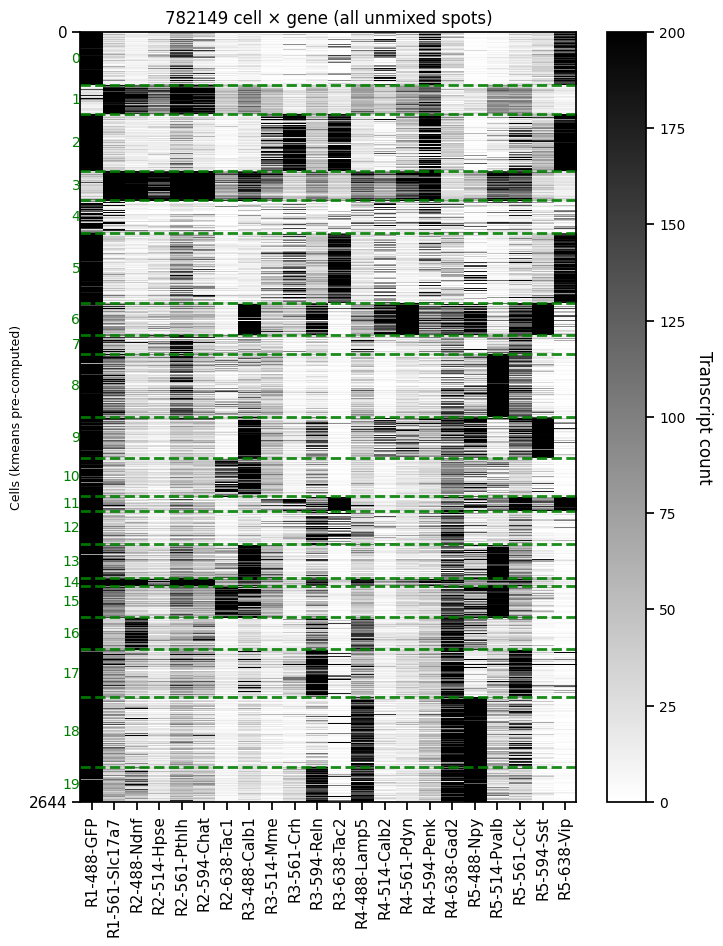

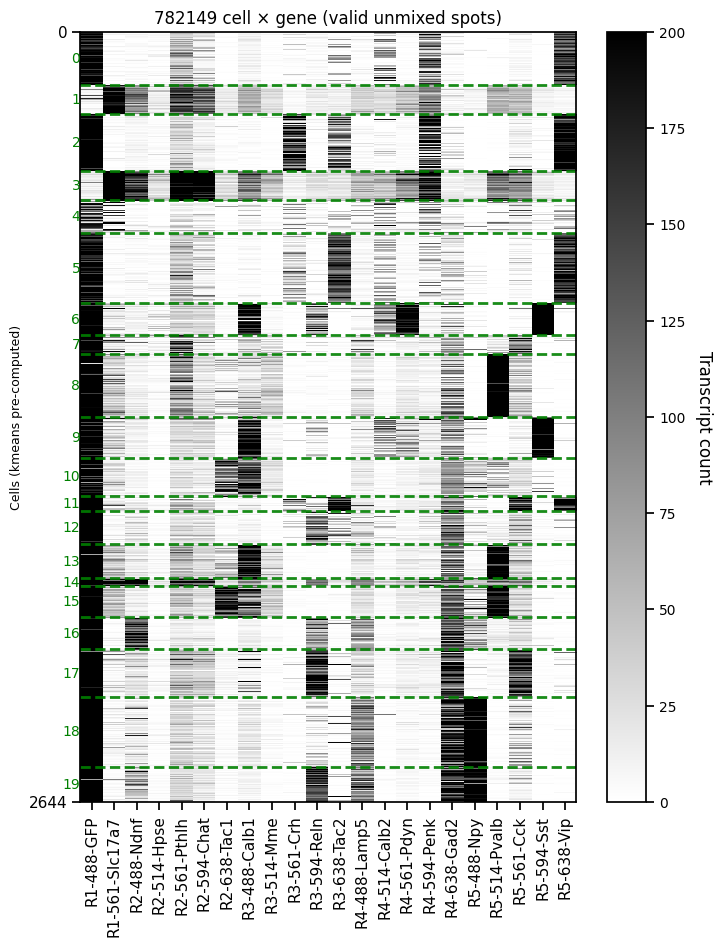

In [22]:
# Cell × gene heatmap — all unmixed spots
# Columns are round-chan-gene sorted; rows grouped by pre-computed cluster_label.
atlas_compare.plot_cell_x_gene_with_clusters(
    spots=unmixed_spots,
    cluster_meta=cluster_meta,
    gene_labels=gene_labels,
    chan_col="unmixed_gene",
    clip_range=(0, 200),
    figsize=(8, 10),
    title=f"{MOUSE_ID} cell × gene (all unmixed spots)",
)

# Cell × gene heatmap — valid unmixed spots only
atlas_compare.plot_cell_x_gene_with_clusters(
    spots=unmixed_spots_valid,
    cluster_meta=cluster_meta,
    gene_labels=gene_labels,
    chan_col="unmixed_gene",
    clip_range=(0, 200),
    figsize=(8, 10),
    title=f"{MOUSE_ID} cell × gene (valid unmixed spots)",
)


# compare to ref

In [8]:
v1_merfish_cells = pd.read_csv("/root/capsule/code/v1_merfish_cells.csv", index_col=0)
abc_atlas_path = Path("/root/capsule/data/abc_atlas/")

# Drop deep layers not relevant to our HCR panel
DROP_LAYERS = ["VISp6a", "VISp6b"]
v1_merfish_cells = v1_merfish_cells[
    ~v1_merfish_cells["parcellation_substructure"].isin(DROP_LAYERS)
]
print(f"V1 cells after dropping {DROP_LAYERS}: {len(v1_merfish_cells):,}")
print(v1_merfish_cells["parcellation_substructure"].value_counts().to_string())


V1 cells after dropping ['VISp6a', 'VISp6b']: 49,853
parcellation_substructure
VISp2/3    21574
VISp4      12977
VISp5      10991
VISp1       4311


In [9]:
import anndata
import warnings
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

warnings.filterwarnings("ignore")

abc_cache = AbcProjectCache.from_cache_dir(Path("/root/capsule/data/abc_atlas"))
abc_cache.current_manifest


'releases/20260415/manifest.json'

In [11]:
hcr_genes = unmixed_spots["unmixed_gene"].unique()
print(f"HCR genes: {hcr_genes}")

HCR genes: ['GFP' 'Slc17a7' nan 'Ndnf' 'Hpse' 'Pthlh' 'Chat' 'Tac1' 'Calb1' 'Mme'
 'Crh' 'Reln' 'Tac2' 'Lamp5' 'Calb2' 'Pdyn' 'Penk' 'Gad2' 'Npy' 'Pvalb'
 'Cck' 'Sst' 'Vip']


In [10]:
# ── Load ABC Atlas MERFISH reference ─────────────────────────────────────────
# All loading, subsetting, filtering, and label-building in one call.
# Tune these three knobs and re-run; everything downstream stays the same.

REF_CLASSES     = ["07 CTX-MGE GABA", "06 CTX-CGE GABA"]
REF_LABEL_LEVEL = "supertype"    # "class" | "subclass" | "supertype" | "cluster"
MIN_LABEL_CELLS = 10             # drop labels with fewer cells than this

# Load cell metadata once and reuse across calls (avoids repeated disk reads)
ref_cell_meta = abc_cache.get_metadata_dataframe(
    directory="MERFISH-C57BL6J-638850",
    file_name="cell_metadata_with_cluster_annotation",
    dtype={"cell_label": str, "neurotransmitter": str},
)
ref_cell_meta.set_index("cell_label", inplace=True)
print(f"ref_cell_meta: {ref_cell_meta.shape}")

ref_counts_filt, ref_labels_filt = atlas_compare.load_abc_merfish_reference(
    abc_cache_dir    = Path("/root/capsule/data/abc_atlas"),
    genes            = hcr_genes,
    cell_index       = v1_merfish_cells.index,   # restrict to V1 cells
    ref_classes      = REF_CLASSES,
    label_level      = REF_LABEL_LEVEL,
    min_label_cells  = MIN_LABEL_CELLS,
    save_dir         = OUTPUT_DIR,    # e.g. OUTPUT_DIR / "ref" to save CSVs
    abc_cache        = abc_cache,
    ref_cell_meta    = ref_cell_meta,
)


ref_cell_meta: (3938808, 20)


NameError: name 'hcr_genes' is not defined

In [26]:
# ── Compare raw vs unmixed expression to reference ───────────────────────────
# atlas_compare computes reference centroids internally:
#   1. Normalises ref_counts -> CP10K
#   2. Groups by ref_labels -> mean()  (these ARE the centroids)
#   3. For each observed cluster: cosine similarity -> best-match reference
#   4. Computes log2 observed/expected per cluster x gene
#
# Use ref_labels_filt (class level) for a coarse match, or switch to "subclass"
# earlier for finer-grained centroids.

comparison, cluster_matches = atlas_compare.raw_unmixed_reference_comparison(
    raw_spots=mixed_spots,
    unmixed_spots=unmixed_spots,
    cell_meta=cluster_meta,
    group_col="cluster_label",
    ref_counts=ref_counts_filt,
    ref_labels=ref_labels_filt,
    raw_chan_col="mixed_gene",
    unmixed_chan_col="unmixed_gene",
    matching_source="unmixed",
)

print("cluster -> reference matches:")
print(cluster_matches)

cluster -> reference matches:
                    reference_label  match_score
group                                           
0                   0178 Vip Gaba_6     0.985632
1                   0174 Vip Gaba_2     0.986672
2      0204 Pvalb chandelier Gaba_1     0.973627
3                   0174 Vip Gaba_2     0.989427
4                 0200 Lamp5 Gaba_2     0.971299
5                   0175 Vip Gaba_3     0.988692
6                   0178 Vip Gaba_6     0.987398
7      0204 Pvalb chandelier Gaba_1     0.989373
8                  0223 Sst Gaba_10     0.989822
9      0204 Pvalb chandelier Gaba_1     0.988927
10                0208 Pvalb Gaba_4     0.988935
11                 0223 Sst Gaba_10     0.988166
12     0204 Pvalb chandelier Gaba_1     0.986894
13                 0187 Sncg Gaba_3     0.989089
14                0200 Lamp5 Gaba_2     0.984718
15                0207 Pvalb Gaba_3     0.989017
16                0200 Lamp5 Gaba_2     0.994112
17                0200 Lamp5 Gaba_2    

In [ ]:
atlas_compare.save_all_figures(
    comparison      = comparison,
    cluster_matches = cluster_matches,
    gene_labels     = gene_labels,
    output_dir      = OUTPUT_DIR / "atlas_compare",
    dpi             = 150,
)

## Individual plots

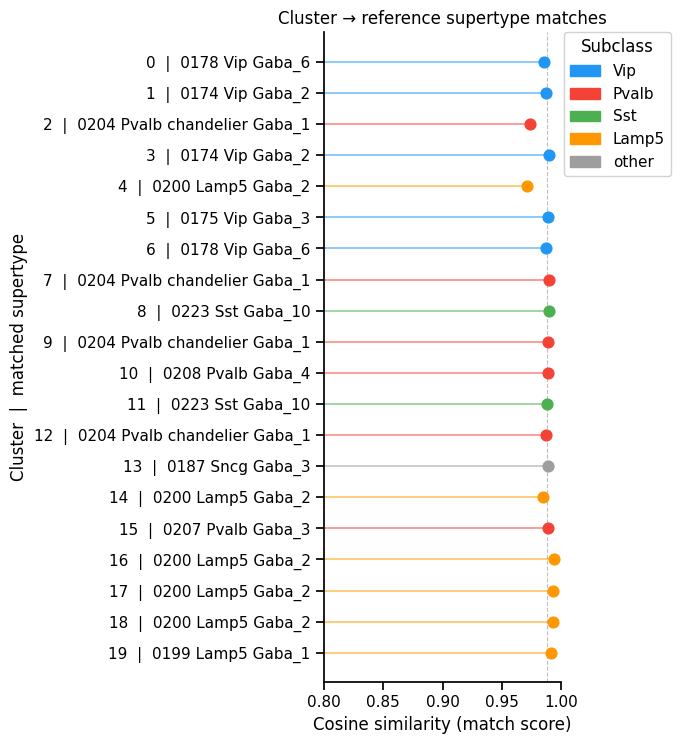

In [58]:
# Which reference supertype did each cluster match to, and how confidently?
atlas_compare.plot_supertype_match_summary(cluster_matches)

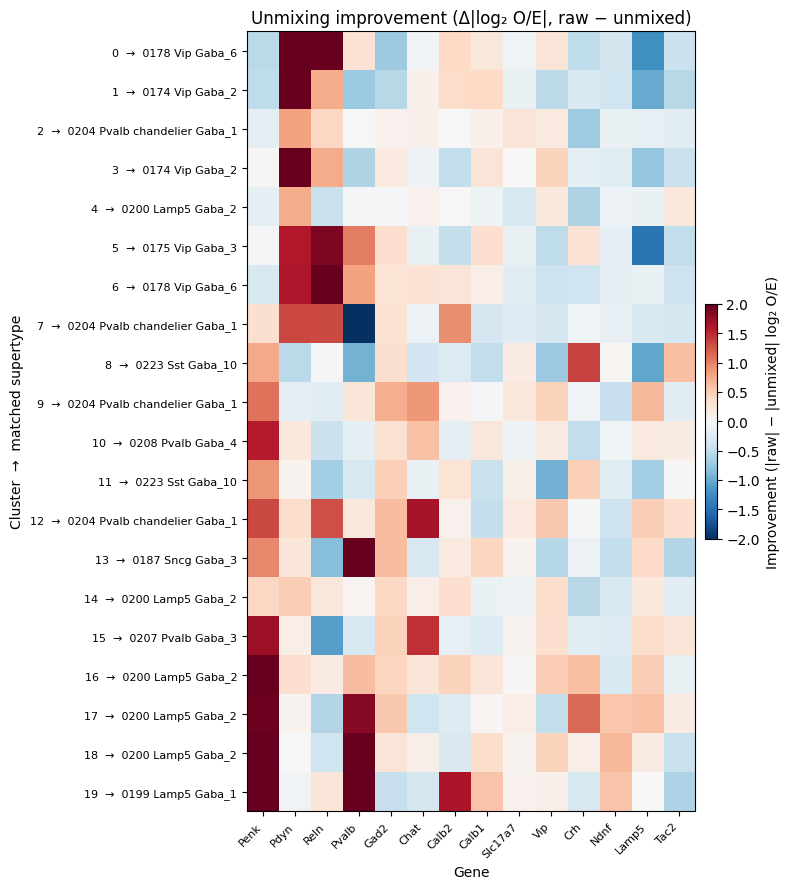

In [59]:
# Heatmap: improvement per cluster x gene.
# Warm (red) = gene got closer to reference after unmixing.
# Cool (blue) = gene moved further away.
# Row labels show cluster → matched supertype.
atlas_compare.plot_improvement_heatmap(
    comparison,
    cluster_matches=cluster_matches,
    row_sort="natural",
    col_sort="mean_improvement",
)


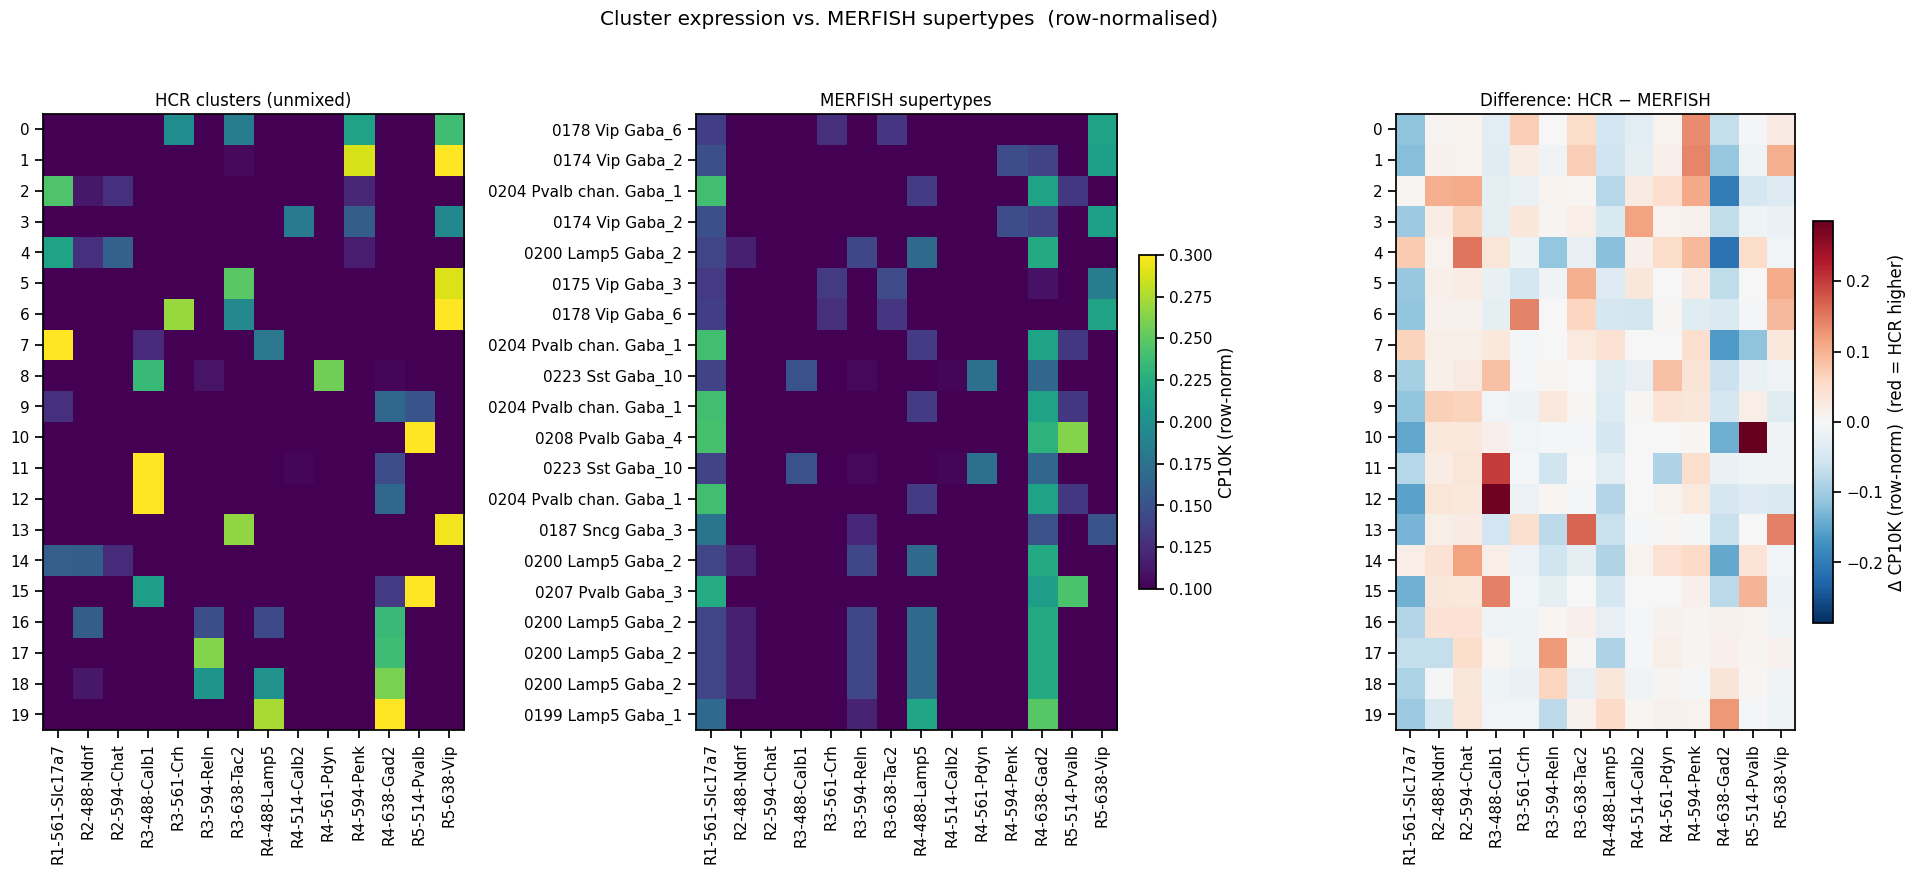

In [57]:
atlas_compare.plot_cluster_reference_expression(
    comparison      = comparison,
    cluster_matches = cluster_matches,
    gene_labels     = gene_labels,   # "R1-488-Gene" ordering
    use_unmixed     = True,
    log_transform   = False,
    normalize       = "row",
    vmax            = 0.3,          # clip to expose dim genes; set None for auto
    vmin           = 0.1
)


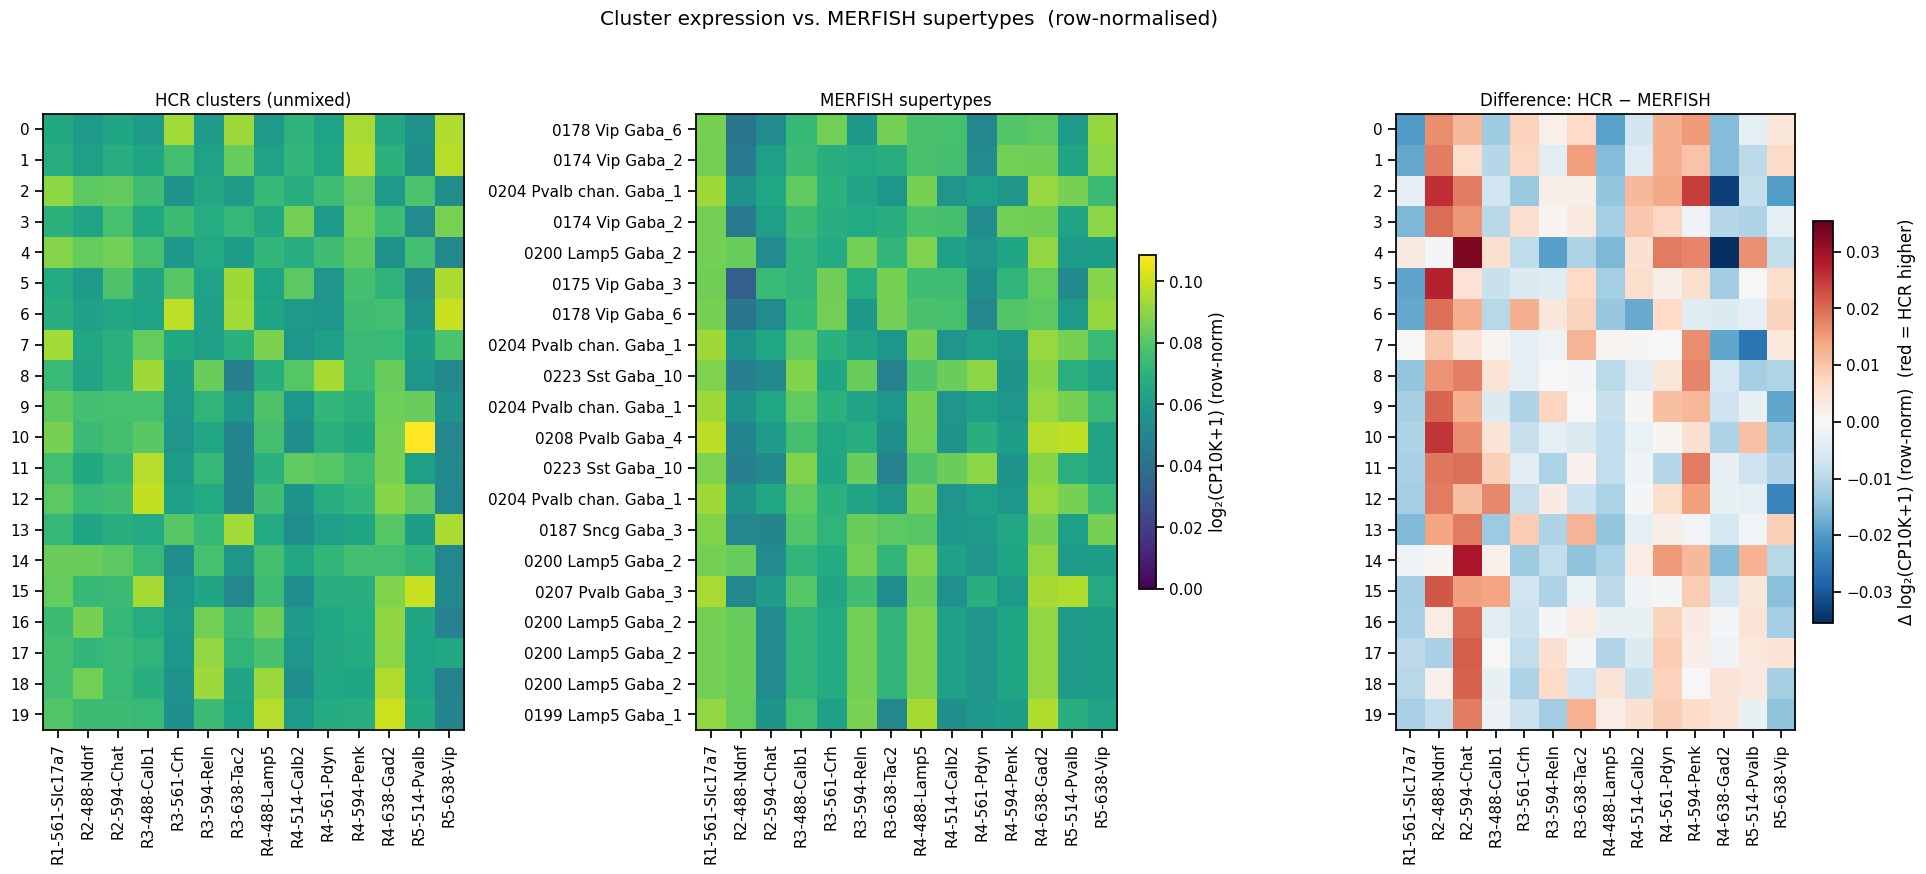

In [52]:
# ── Side-by-side expression heatmaps ─────────────────────────────────────────
# Left:  HCR cluster × gene  (unmixed CP10K, row-normalised)
# Right: Matched reference supertype × gene  (reference CP10K, row-normalised)
# Rows are aligned - cluster N faces its matched supertype.
# Genes are ordered by round-channel (uses gene_labels built above).

atlas_compare.plot_cluster_reference_expression(
    comparison      = comparison,
    cluster_matches = cluster_matches,
    gene_labels     = gene_labels,   # "R1-488-Gene" ordering
    use_unmixed     = True,
    log_transform   = True,
    normalize       = "row",
    #vmax            = 0.9,          # clip to expose dim genes; set None for auto
)


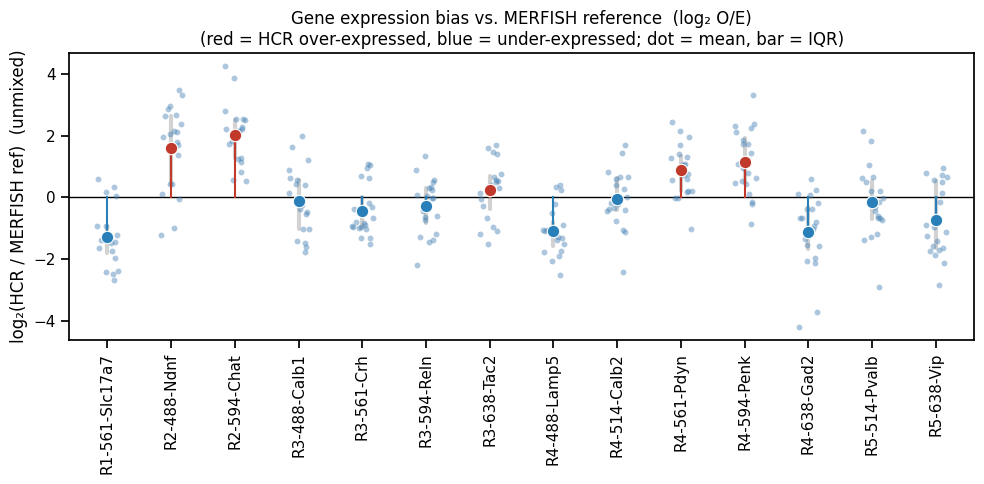

In [60]:
# ── Gene expression bias: aggregate across all clusters ──────────────────────
# Each dot = one cluster's log2(HCR / MERFISH ref) for that gene.
# Red dot + stem = mean; gray bar = IQR (25th–75th percentile).
# Genes above 0 are systematically over-expressed in HCR; below 0 = under.
atlas_compare.plot_gene_expression_bias(
    comparison  = comparison,
    gene_labels = gene_labels,
    use_unmixed = True,
)

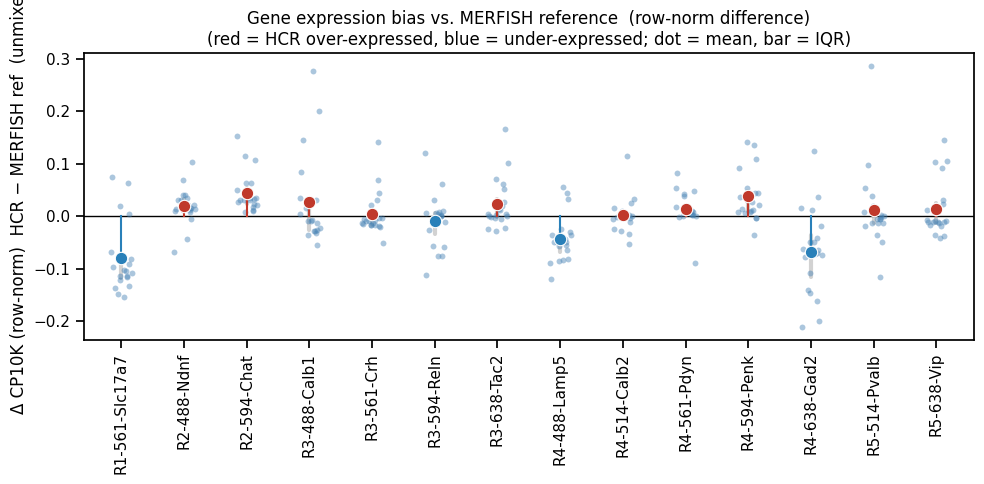

In [61]:
# ── Same plot, but using row-normalised fraction difference ───────────────────
# Values = (HCR row-norm fraction) − (MERFISH row-norm fraction) per cluster×gene.
# Tells a slightly different story: which genes claim more/less share of the
# total expression profile in HCR vs the reference.
atlas_compare.plot_gene_expression_bias(
    comparison  = comparison,
    gene_labels = gene_labels,
    use_unmixed = True,
    normalize   = "row",
)

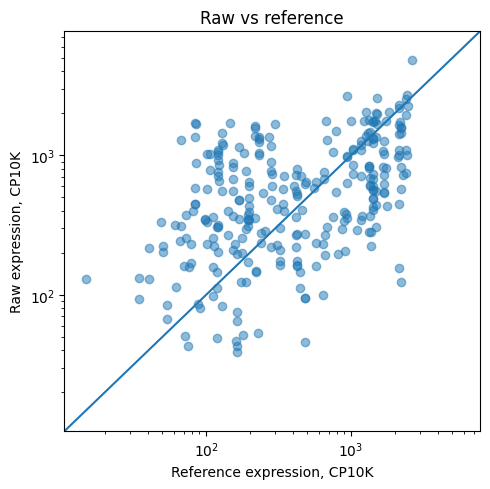

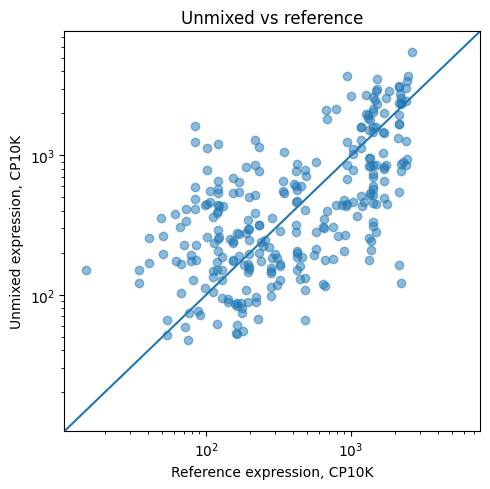

In [ ]:
# Scatter: raw vs reference  (use_unmixed=False)
atlas_compare.plot_reference_scatter(comparison, annotate_genes=[], use_unmixed=False)

# Scatter: unmixed vs reference  (use_unmixed=True)
atlas_compare.plot_reference_scatter(comparison, annotate_genes=[], use_unmixed=True)

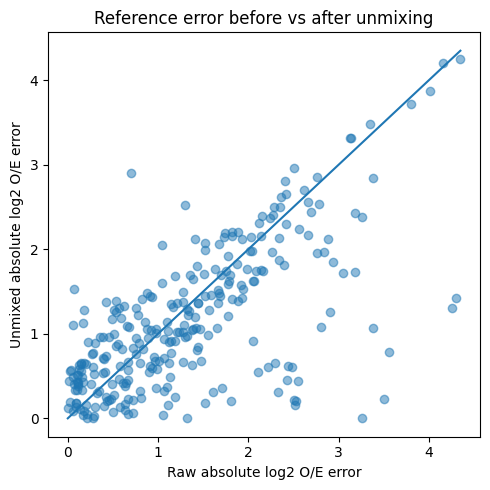

In [30]:
atlas_compare.plot_error_improvement(comparison)

ERROR:autoreload:Failed to reload module 'atlas_compare' from file '/code/atlas_compare.py'
Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 451, in update_generic
    update(a, b)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 363, in update_function
    setattr(old, name, getattr(new, name))
ValueError: plot_reference_scatter() requires a code object with 0 free vars, not 2
[autoreload of atlas_compare failed: Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_obje

Saved 10 figures to: /root/capsule/scratch/ref_atlas_validation/782149/atlas_compare
  01_supertype_match_summary.png
  02_improvement_heatmap.png
  03_expression_heatmap_row_norm.png
  04_expression_heatmap_col_norm.png
  05_expression_heatmap_no_norm_log2.png
  06_gene_bias_log2_oe.png
  07_gene_bias_row_norm_diff.png
  08_reference_scatter_raw.png
  09_reference_scatter_unmixed.png
  10_error_improvement.png


# all mice results

In [3]:
import atlas_compre

ModuleNotFoundError: No module named 'atlas_compre'

In [4]:
import pandas as pd

f1 = "/root/capsule/scratch/ref_atlas_validation/_combined/comparison_all.csv"
f2 = "/root/capsule/scratch/ref_atlas_validation/_combined/cluster_matches_all.csv"

comparison_all    = pd.read_csv(f1)
cluster_matches_all = pd.read_csv(f2)

print(f"comparison_all:     {comparison_all.shape}  mice={sorted(comparison_all.mouse_id.unique())}  filters={sorted(comparison_all.spot_filter.unique())}")
print(f"cluster_matches_all:{cluster_matches_all.shape}")


comparison_all:     (4200, 13)  mice=['755252', '755252-legacy', '767022', '767022-legacy', '782149', '782149-legacy', '788406', '790322']  filters=['all', 'valid']
cluster_matches_all:(320, 5)


In [30]:
comparison_all.gene.unique()

array(['Calb1', 'Calb2', 'Crh', 'Gad2', 'Lamp5', 'Ndnf', 'Nos1', 'Pdyn',
       'Pvalb', 'Reln', 'Tac2', 'Vip'], dtype=object)

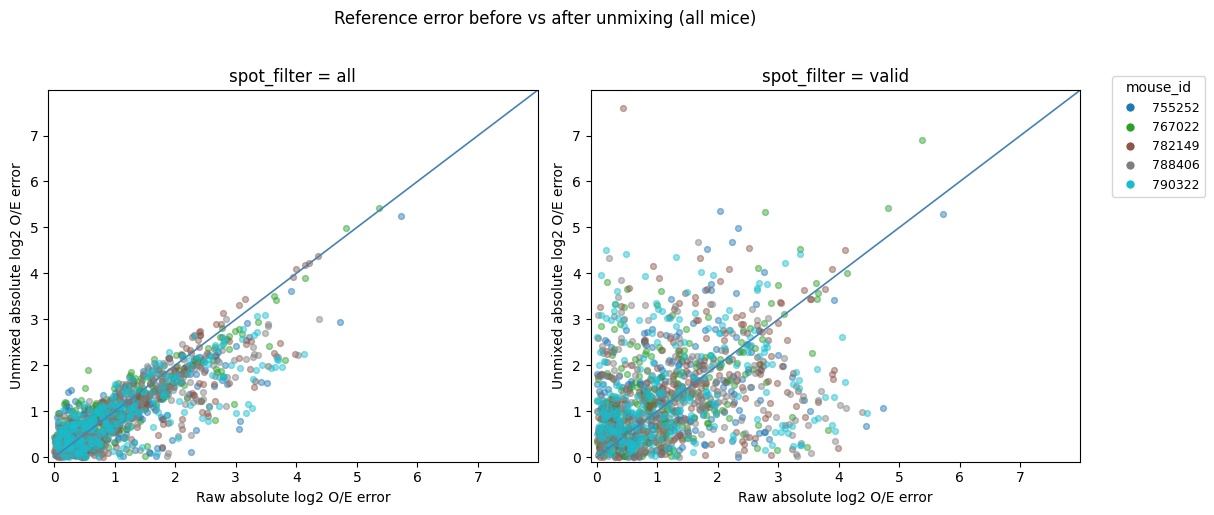

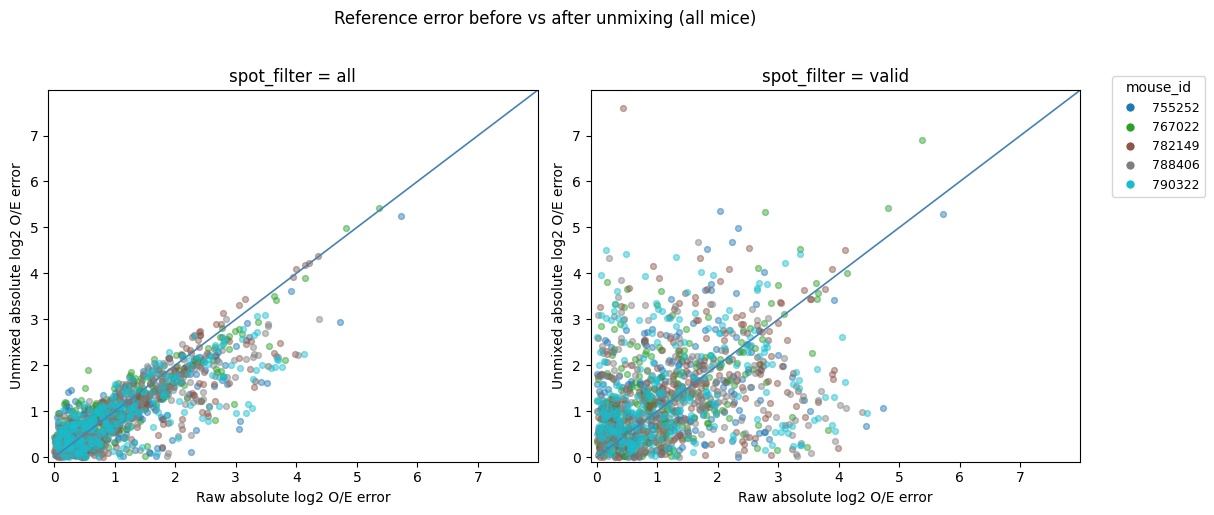

In [7]:
# Raw vs unmixed absolute error — one panel per spot_filter, coloured by mouse
atlas_compare.plot_multi_mouse_error_improvement(comparison_all)


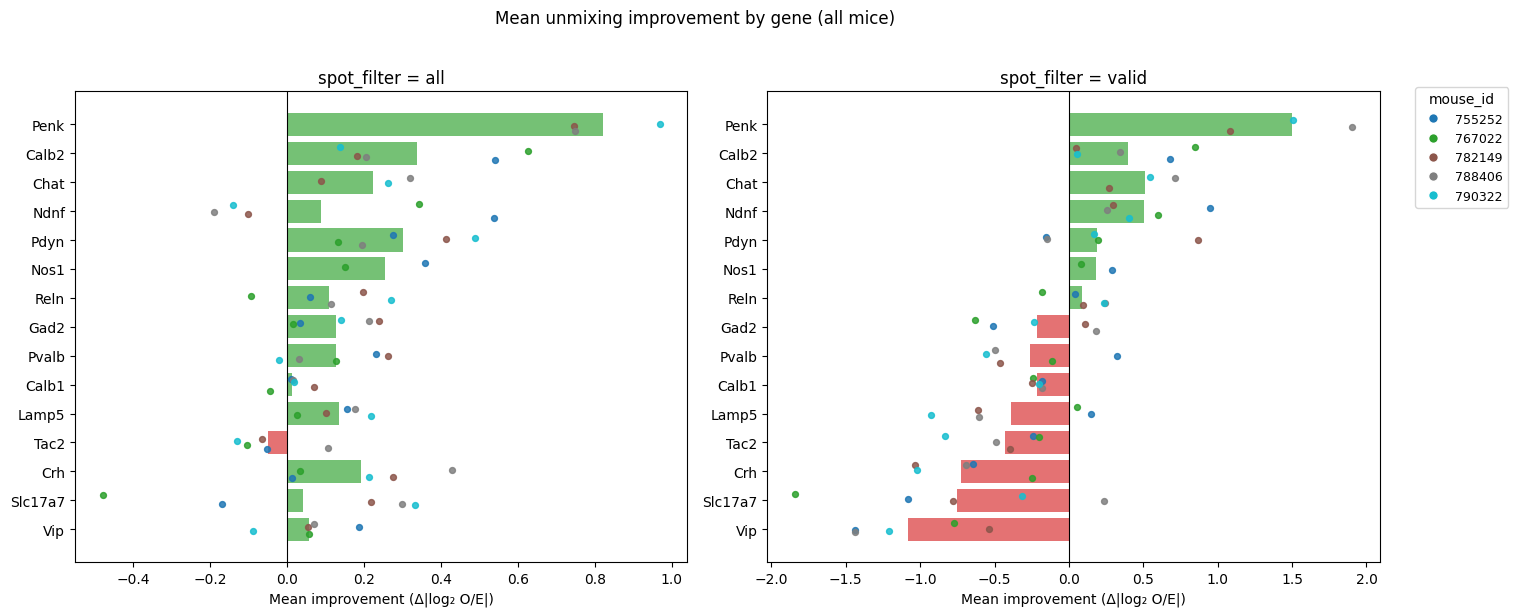

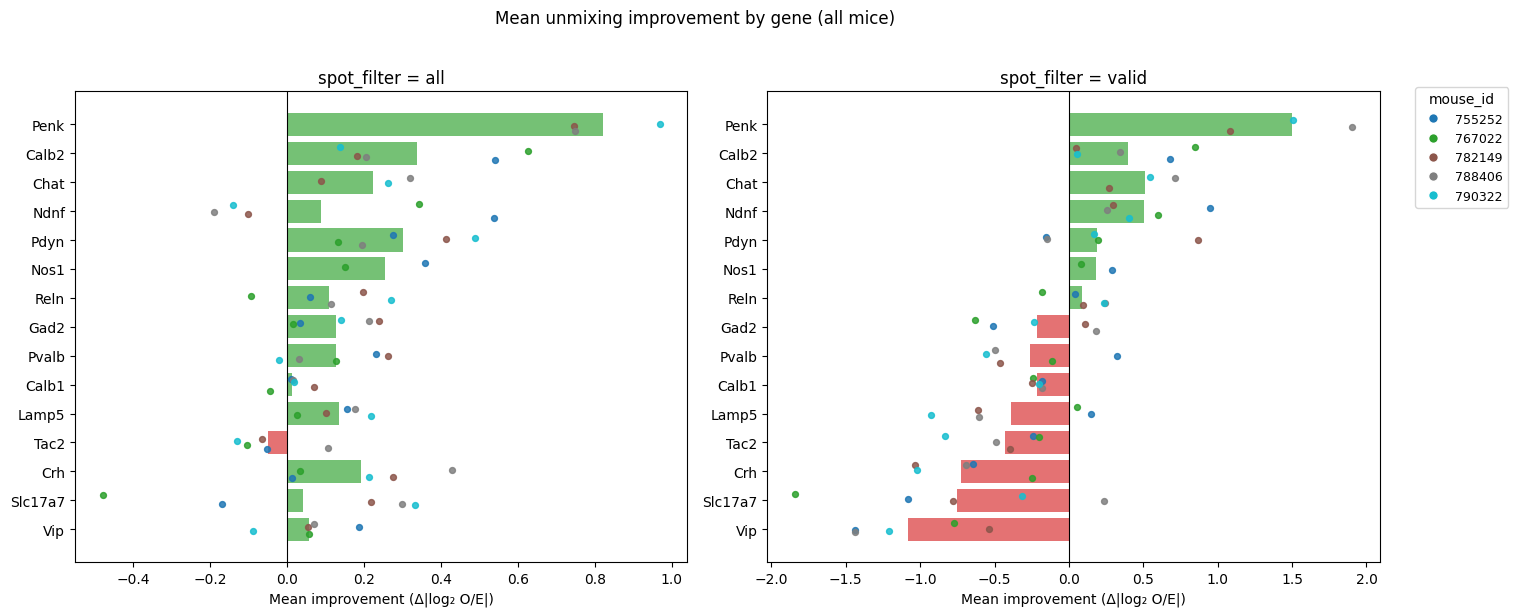

In [8]:
# Mean improvement per gene, with per-mouse dots — one panel per spot_filter
atlas_compare.plot_multi_mouse_improvement_by_gene(comparison_all)


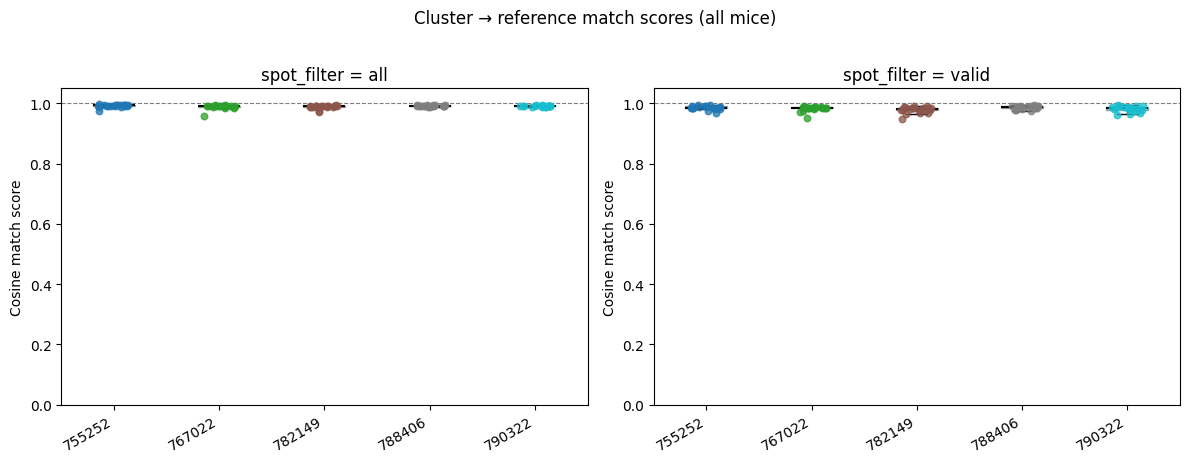

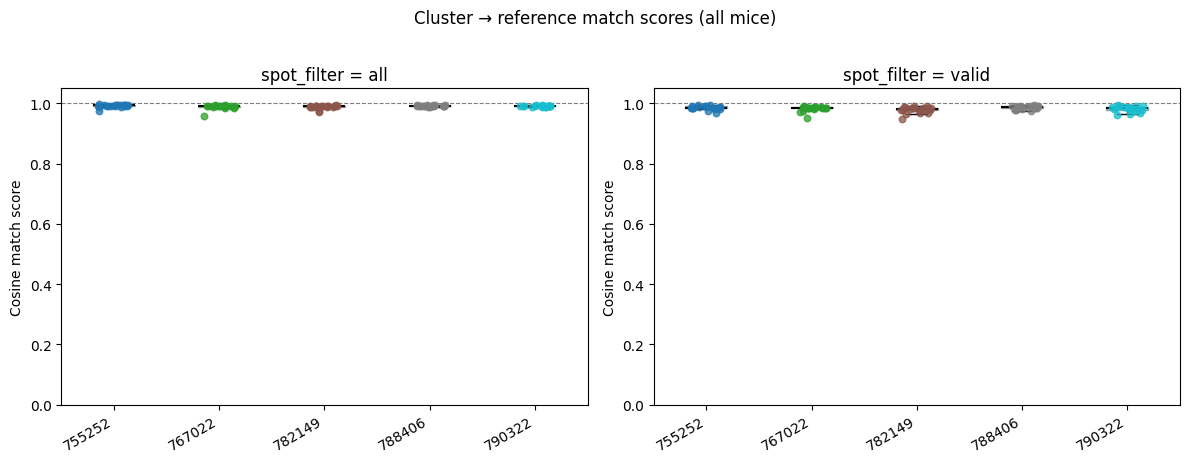

In [9]:
# Cluster-to-reference match score distribution per mouse — one panel per spot_filter
atlas_compare.plot_multi_mouse_match_scores(cluster_matches_all)


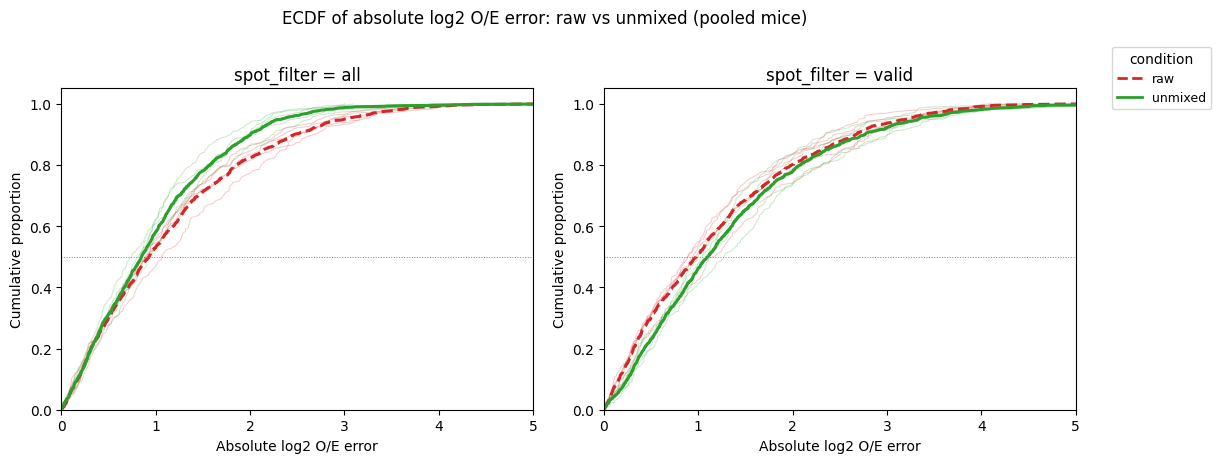

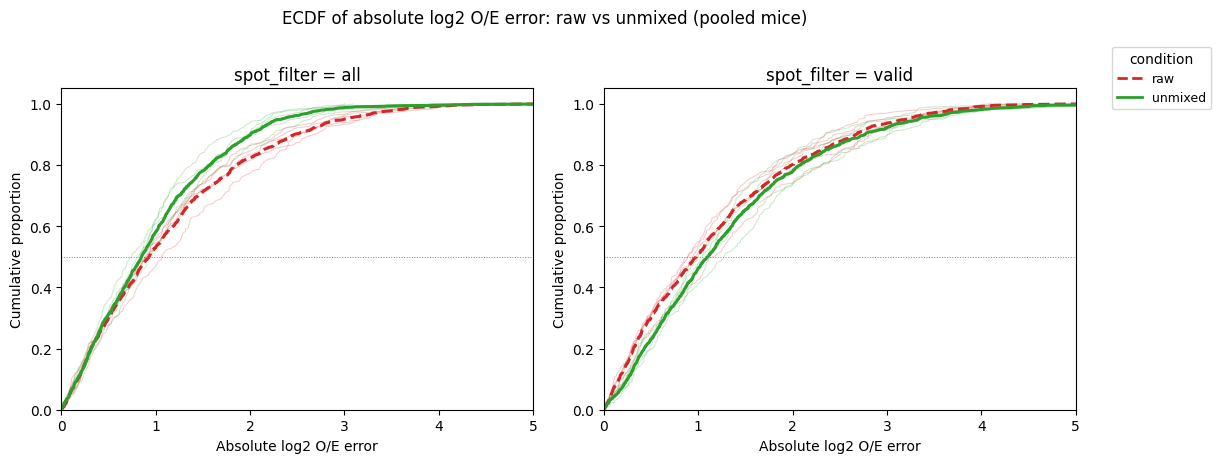

In [13]:
# ECDF: raw vs unmixed error — one panel per spot_filter, dashed=raw solid=unmixed
atlas_compare.plot_multi_mouse_error_ecdf(comparison_all)


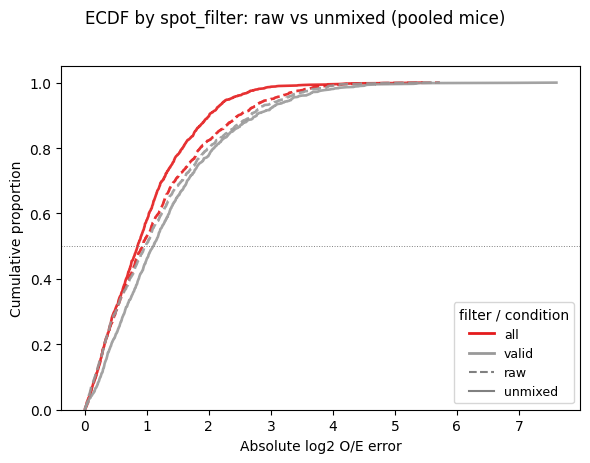

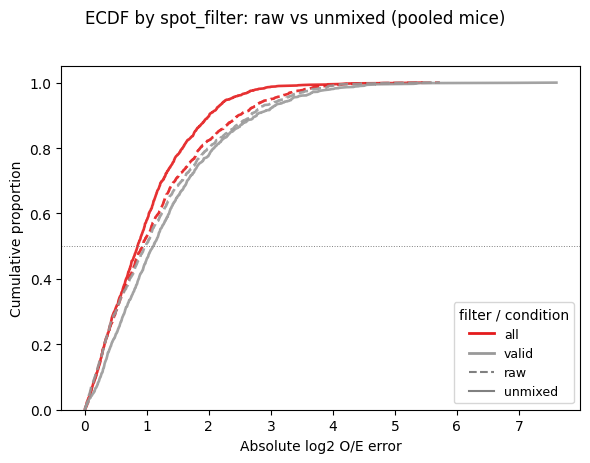

In [11]:
# ECDF: valid vs other spot_filter values — one panel per mouse, coloured by filter
atlas_compare.plot_multi_mouse_filter_ecdf(comparison_all)


# legacy mice too

In [5]:
import pandas as pd

f1 = "/root/capsule/scratch/ref_atlas_validation/_combined/comparison_all.csv"
f2 = "/root/capsule/scratch/ref_atlas_validation/_combined/cluster_matches_all.csv"

comparison_all    = pd.read_csv(f1)
cluster_matches_all = pd.read_csv(f2)

print(f"comparison_all:     {comparison_all.shape}  mice={sorted(comparison_all.mouse_id.unique())}  filters={sorted(comparison_all.spot_filter.unique())}")
print(f"cluster_matches_all:{cluster_matches_all.shape}")


comparison_all:     (4200, 13)  mice=['755252', '755252-legacy', '767022', '767022-legacy', '782149', '782149-legacy', '788406', '790322']  filters=['all', 'valid']
cluster_matches_all:(320, 5)


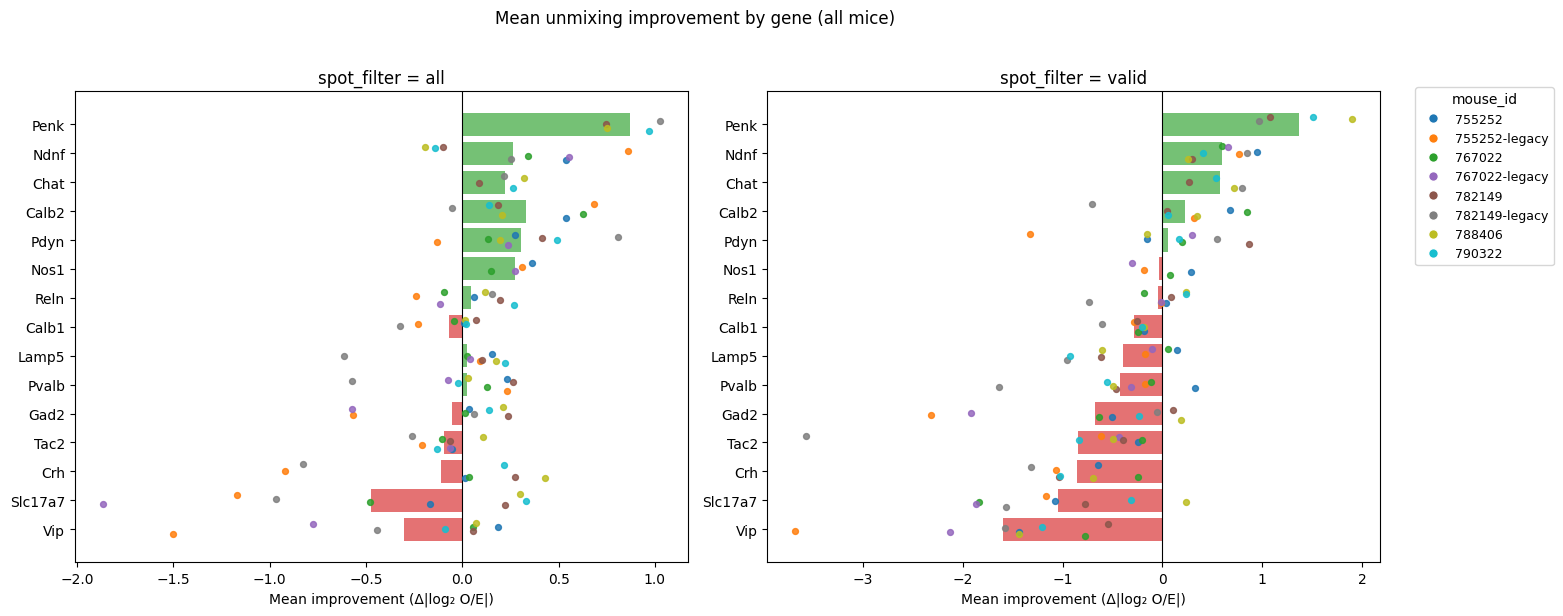

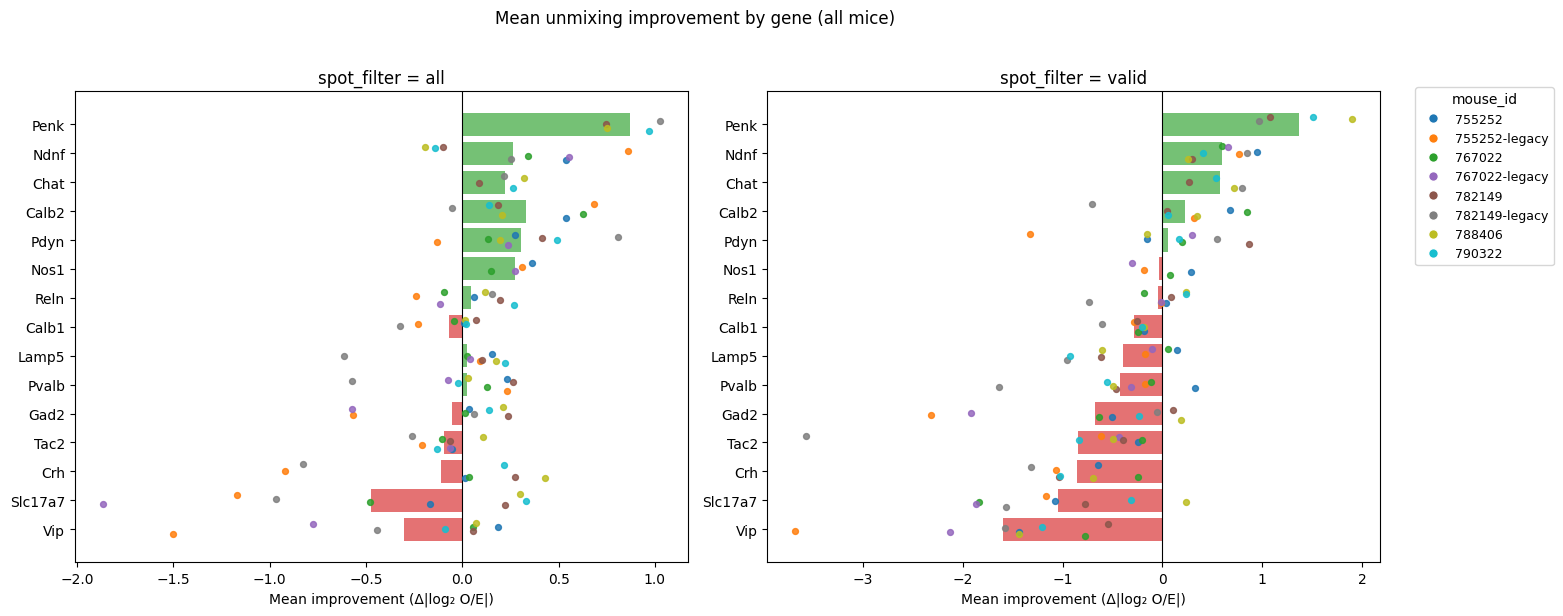

In [6]:
# Mean improvement per gene, with per-mouse dots — one panel per spot_filter
atlas_compare.plot_multi_mouse_improvement_by_gene(comparison_all)